In [56]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot(title, label, x, result, expected):
    plt.plot(x, expected, label=f'Ground truth')
    plt.plot(x, result, label=f'Sequre {label}')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

def mae(result, expected):
    return np.mean(np.abs(np.array(result) - np.array(expected)))

def mxae(result, expected):
    return np.max(np.abs(np.array(result) - np.array(expected)))

def by_interval(df):
    for interval, group in df.groupby('Interval'):
        display(group)

In [57]:
""" Core methods """

# Until Codon Jupyter is fixed: Read the data from files
show_plots = False

dump_folder = "dump-gcp"
dump_files = [
    "decor_trig",
    "decor",
    "fourier",
    "cheby",
    "taylor"
    ]
nbit_fs = [32, 64]
intervals_count = 4
cps = [0, 1]
exclude = ["sinh", "cosh", "tanh"]

df_data = {
    'Method': [],
    'Interval': [],
    'MAE': [],
    'MXAE': [],
    'Runtime': [],
    'Partitions count': [],
    'Truncations count': []
    }

for cp in cps:
    df_data[f'Bytes sent CP{cp}'] = []
    df_data[f'Requests sent CP{cp}'] = []

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        for i in range(intervals_count):
            for cp in cps:
                try:
                    with open(f"{dump_folder}/{dump_file}_{i}_{nbit_f}_CP{cp}.p", "rb") as f:
                        data = pickle.load(f)
                        x = data['x']
                        interval = f"({round(min(x), 2)}, {round(max(x), 2)})"
                        for k, v in data.items():
                            if not k.endswith('_result'):
                                continue

                            skip = False
                            for exclude_item in exclude:
                                if exclude_item in k:
                                    skip = True
                                    break
                            
                            if skip:
                                continue

                            k = k.replace('_result', '')
                            expected = data[f"{k}_expected"]

                            runtime = round(data[f"{k}_time"][0], 5)
                            bytes_sent = int(data[f"{k}_bytes_sent"][0])
                            send_requests = int(data[f"{k}_send_requests"][0])
                            partitions_count = int(data[f"{k}_partitions_count"][0])
                            truncations_count = int(data[f"{k}_truncations_count"][0])
                            
                            if cp == 1:
                                df_data['Method'].append(f"{k}_{nbit_f}")
                                df_data['Interval'].append(interval)
                                df_data['MAE'].append(mae(v, expected))
                                df_data['MXAE'].append(mxae(v, expected))

                                df_data['Runtime'].append(runtime)
                                df_data['Partitions count'].append(partitions_count)
                                df_data['Truncations count'].append(truncations_count)

                            df_data[f'Bytes sent CP{cp}'].append(bytes_sent)
                            df_data[f'Requests sent CP{cp}'].append(send_requests)
                            
                            if show_plots and cp == 1:
                                plot(f"{k} {nbit_f} frac bits on {interval}", k, x, v, expected)
                except FileNotFoundError:
                    print(f"Could not find {dump_folder}/{dump_file}_{i}_{nbit_f}.p")

df = pd.DataFrame(df_data)

In [58]:
if df.empty:
    raise ValueError("DataFrame is empty")

display_methods = [
    "sin_", "cos_", "tan_", "cot", "exp",
    "sigmoid", "sinh", "cosh", "tanh",
    "sqrt", "log", "mul_inv", "polynomial"]

for method in display_methods:
    display(by_interval(df[df['Method'].str.contains(method)].sort_values(by='MAE')))

,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
16,decor_sin_64,"(-0.79, 0.79)",6.563725e-16,2.192690e-15,0.00040,1,0,64064,8,17617,2
202,chebyshev_17_sin_clenshaw_64,"(-0.79, 0.79)",1.332243e-15,1.088019e-14,0.00927,17,19,880880,110,576576,72
194,chebyshev_17_sin_naive_64,"(-0.79, 0.79)",1.334593e-15,1.088019e-14,0.01245,17,19,880896,110,576584,72
195,chebyshev_17_sin_decor_64,"(-0.79, 0.79)",1.336929e-15,1.054712e-14,0.03249,28,4,600672,54,328720,66
129,chebyshev_10_sin_naive_32,"(-0.79, 0.79)",1.330315e-10,3.028254e-10,0.00757,10,12,408560,68,264360,44
125,chebyshev_10_sin_clenshaw_32,"(-0.79, 0.79)",2.746808e-10,9.705673e-10,0.00595,10,12,408544,68,264352,44
6,decor_sin_32,"(-0.79, 0.79)",8.119323e-10,1.725726e-09,0.00053,1,0,48064,8,13217,2
135,chebyshev_10_sin_decor_32,"(-0.79, 0.79)",1.724350e-09,1.374893e-08,0.01644,24,4,332568,50,180624,58
258,taylor_6_sin_decor_32,"(-0.79, 0.79)",4.604479e-06,3.626454e-05,0.01231,24,3,260504,46,168608,56
260,taylor_6_sin_naive_32,"(-0.79, 0.79)",4.604570e-06,3.626464e-05,0.00450,6,7,240336,40,156216,26


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
11,decor_sin_64,"(-10.0, 10.0)",5.185470e-16,2.539635e-15,0.00067,1,0,64064,8,17617,2
1,decor_sin_32,"(-10.0, 10.0)",5.482329e-10,1.596058e-09,0.00074,1,0,48064,8,13217,2
166,chebyshev_17_sin_clenshaw_64,"(-10.0, 10.0)",5.881618e-05,1.615646e-04,0.01073,17,19,880880,110,576576,72
161,chebyshev_17_sin_naive_64,"(-10.0, 10.0)",5.881618e-05,1.615646e-04,0.01342,17,19,880896,110,576584,72
162,chebyshev_17_sin_decor_64,"(-10.0, 10.0)",6.048735e-05,2.540089e-04,0.03323,28,4,600672,54,328720,66
44,fourier_10_sin_32,"(-10.0, 10.0)",3.708899e-02,5.440211e-01,0.00364,0,1,480384,8,121297,2
68,fourier_10_sin_64,"(-10.0, 10.0)",3.708899e-02,5.440211e-01,0.00408,0,1,640384,8,161697,2
92,chebyshev_10_sin_naive_32,"(-10.0, 10.0)",1.804739e-01,3.740797e-01,0.00787,10,12,408560,68,264360,44
99,chebyshev_10_sin_clenshaw_32,"(-10.0, 10.0)",1.804739e-01,3.740797e-01,0.00741,10,12,408544,68,264352,44
236,taylor_6_sin_decor_32,"(-10.0, 10.0)",1.031936e+02,6.772107e+02,0.01196,24,3,260504,46,168608,56


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
19,decor_sin_64,"(0.79, 2.36)",2.726708e-16,1.110223e-15,0.00062,1,0,64064,8,17617,2
225,chebyshev_17_sin_clenshaw_64,"(0.79, 2.36)",1.896483e-15,1.110223e-14,0.00985,17,19,880880,110,576576,72
209,chebyshev_17_sin_naive_64,"(0.79, 2.36)",1.896927e-15,1.110223e-14,0.01277,17,19,880896,110,576584,72
221,chebyshev_17_sin_decor_64,"(0.79, 2.36)",1.918465e-15,1.110223e-14,0.03358,28,4,600672,54,328720,66
143,chebyshev_10_sin_naive_32,"(0.79, 2.36)",1.199587e-10,5.533060e-10,0.00736,10,12,408560,68,264360,44
141,chebyshev_10_sin_clenshaw_32,"(0.79, 2.36)",2.646431e-10,9.764082e-10,0.00609,10,12,408544,68,264352,44
9,decor_sin_32,"(0.79, 2.36)",3.732050e-10,1.262773e-09,0.00060,1,0,48064,8,13217,2
159,chebyshev_10_sin_decor_32,"(0.79, 2.36)",4.583903e-09,2.516975e-08,0.01678,24,4,332568,50,180624,58
317,taylor_6_sin_decor_64,"(0.79, 2.36)",4.031332e-07,3.566364e-06,0.01455,28,3,392552,50,312704,64
311,taylor_6_sin_naive_64,"(0.79, 2.36)",4.031332e-07,3.566364e-06,0.00494,6,7,320336,40,208216,26


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
13,decor_sin_64,"(3.14, 9.42)",3.399317e-16,1.942890e-15,0.00046,1,0,64064,8,17617,2
72,fourier_10_sin_64,"(3.14, 9.42)",3.499176e-16,1.543904e-15,0.00084,0,1,64096,8,17625,2
172,chebyshev_17_sin_naive_64,"(3.14, 9.42)",5.009824e-14,1.540006e-13,0.01247,17,19,880896,110,576584,72
187,chebyshev_17_sin_clenshaw_64,"(3.14, 9.42)",5.010358e-14,1.539792e-13,0.01000,17,19,880880,110,576576,72
183,chebyshev_17_sin_decor_64,"(3.14, 9.42)",2.268710e-13,5.023482e-12,0.03308,28,4,600672,54,328720,66
3,decor_sin_32,"(3.14, 9.42)",5.232004e-10,1.488962e-09,0.00082,1,0,48064,8,13217,2
48,fourier_10_sin_32,"(3.14, 9.42)",5.284314e-10,1.729059e-09,0.00104,0,1,48096,8,13225,2
106,chebyshev_10_sin_naive_32,"(3.14, 9.42)",3.765439e-06,6.036097e-06,0.00772,10,12,408560,68,264360,44
105,chebyshev_10_sin_clenshaw_32,"(3.14, 9.42)",3.765489e-06,6.036167e-06,0.00748,10,12,408544,68,264352,44
120,chebyshev_10_sin_decor_32,"(3.14, 9.42)",3.765626e-06,6.034654e-06,0.01645,24,4,332568,50,180624,58


None

...

,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
40,decor_polynomial_64,"(-0.79, 0.79)",8.150986e-16,4.440892e-15,0.01229,28,3,344528,50,312704,64
28,decor_polynomial_32,"(-0.79, 0.79)",1.702860e-09,8.381297e-09,0.01044,24,3,224480,46,168608,56


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
34,decor_polynomial_64,"(-10.0, 10.0)",1.069499e-12,7.730705e-12,0.01432,28,3,344528,50,312704,64
22,decor_polynomial_32,"(-10.0, 10.0)",1.577243e-05,9.402889e-05,0.01043,24,3,224480,46,168608,56


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
43,decor_polynomial_64,"(0.79, 2.36)",6.988188e-15,4.263256e-14,0.01251,28,3,344528,50,312704,64
31,decor_polynomial_32,"(0.79, 2.36)",1.323282e-08,4.444267e-08,0.01107,24,3,224480,46,168608,56


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
37,decor_polynomial_64,"(3.14, 9.42)",3.208243e-13,1.364242e-12,0.01255,28,3,344528,50,312704,64
25,decor_polynomial_32,"(3.14, 9.42)",1.925055e-06,6.183287e-06,0.01071,24,3,224480,46,168608,56


None

In [59]:
""" E2E apps """

# Until Codon Jupyter is fixed: Read the data from files
dump_files = [
    "log_reg",
    "dti"
    ]

df_data = {
    'Method': [],
    'Accuracy': [],
    'Runtime': [],
    'Bytes sent': [],
    'Requests sent': [],
    'Partitions count': [],
    'Truncations count': []
    }

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        for cp in cps:
            try:
                with open(f"{dump_folder}/{dump_file}_{nbit_f}_CP{cp}.p", "rb") as f:
                    data = pickle.load(f)
                    for k, v in data.items():
                        if not k.endswith('_accuracy'):
                            continue
                        
                        k = k.replace('_accuracy', '')
                        accuracy = data[f"{k}_accuracy"][0]
                        runtime = round(data[f"{k}_time"][0], 5)
                        bytes_sent = int(data[f"{k}_bytes_sent"][0])
                        send_requests = int(data[f"{k}_send_requests"][0])
                        partitions_count = int(data[f"{k}_partitions_count"][0])
                        truncations_count = int(data[f"{k}_truncations_count"][0])
                        
                        df_data['Method'].append(f"{k}_{nbit_f}")
                        
                        df_data['Accuracy'].append(accuracy)
                        df_data['Runtime'].append(runtime)
                        df_data['Bytes sent'].append(bytes_sent)
                        df_data['Requests sent'].append(send_requests)
                        df_data['Partitions count'].append(partitions_count)
                        df_data['Truncations count'].append(truncations_count)
            except FileNotFoundError:
                print(f"Could not find {dump_folder}/{dump_file}_{nbit_f}_CP{cp}.p")

e2e_df = pd.DataFrame(df_data)

Could not find dump-gcp/log_reg_32_CP1.p
Could not find dump-gcp/log_reg_64_CP1.p
Could not find dump-gcp/dti_32_CP0.p
Could not find dump-gcp/dti_32_CP1.p
Could not find dump-gcp/dti_64_CP0.p
Could not find dump-gcp/dti_64_CP1.p


In [60]:
e2e_df[e2e_df['Method'].str.contains('binary')].sort_values(by='Accuracy', ascending=False)

,Method,Accuracy,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count
1,log_reg_binary_chebyshev_32,1.0,0.04155,359680,1680,241,300
2,log_reg_binary_fourier_32,1.0,0.25135,402560,480,81,80
4,log_reg_binary_decor_32,1.0,0.03240,1038080,7240,3761,560
7,log_reg_binary_chebyshev_64,1.0,0.01029,689760,2520,381,440
8,log_reg_binary_fourier_64,1.0,0.19969,526240,480,81,80
10,log_reg_binary_decor_64,1.0,0.03930,1578720,7800,4281,560


In [61]:
e2e_df[e2e_df['Method'].str.contains('multinomial')].sort_values(by='Accuracy', ascending=False)

,Method,Accuracy,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count
0,log_reg_multinomial_decor_32,1.0,0.08634,4855840,4200,2801,120
3,log_reg_multinomial_fourier_32,1.0,0.69073,5415200,3440,2361,80
5,log_reg_multinomial_chebyshev_32,1.0,0.08681,5280160,4640,2521,300
6,log_reg_multinomial_decor_64,1.0,0.19758,9024320,4280,2881,120
9,log_reg_multinomial_fourier_64,1.0,0.34609,9682560,3440,2361,80
11,log_reg_multinomial_chebyshev_64,1.0,0.14210,10153280,5480,2661,440


In [62]:
e2e_df[e2e_df['Method'].str.contains('dti')].sort_values(by='Accuracy', ascending=False)

,Method,Accuracy,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count


In [63]:
import math


def by_name(name, df):
    return df[df['Method'].str.startswith(name)]

def plot_accuracy_vs_perf(
        df, methods=["sin", "cos", "exp", "sigmoid"],
        metric="Runtime", intervals=["(-10.0, 10.0)"],
        approaches=["decor", "chebyshev", "fourier", "taylor"],
        markers=["o", "s", "^", "v"], remove_outliers=False):
    
    _, axs = plt.subplots(2, 2, figsize=(12, 10))
    for idx, method in enumerate(methods):
        ax = axs[idx // 2, idx % 2]

        filtered_df = df[df['Method'].str.contains(f"{method}_")]
        filtered_df = filtered_df[
            ~filtered_df['Method'].str.contains('_decor') &
            (~filtered_df['Method'].str.contains('_naive') |
             filtered_df['Method'].str.contains('taylor_'))
        ]
        filtered_df['Method'] = filtered_df['Method'].str.replace(f"{method}_", "", regex=False)
        
        if remove_outliers:
            filtered_df = filtered_df[filtered_df['MAE'] < 0.5]
        
        # Convert MAE to accuracy
        filtered_df['MAE'] = filtered_df['MAE'].apply(lambda x: -math.log(x))
        
        for interval, group in filtered_df.groupby('Interval'):
            if interval not in intervals:
                print(f"Skipping interval {interval}")
                continue
            for approach, marker in zip(approaches, markers):
                filtered_group = group[group['Method'].str.startswith(approach)]
                if filtered_group.empty:
                    continue
                ax.scatter(
                    filtered_group[metric], filtered_group["MAE"],
                    label=approach.capitalize(), marker=marker, s=100,
                    edgecolors=[
                        ('black' if m.endswith('64') else 'none') for m in filtered_group['Method']],
                )
            ax.set_title(f"{method} at {interval}")
            ax.set_xlabel(metric)
            ax.set_ylabel("Accuracy: -log(MAE)")
            ax.grid(True)
        if idx == 1:
            ax.legend(title="Bordered: 64 bits\nNon-bordered: 32 bits", loc='upper right')
    
    plt.tight_layout()
    plt.show()

Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)
Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)
Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)
Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)


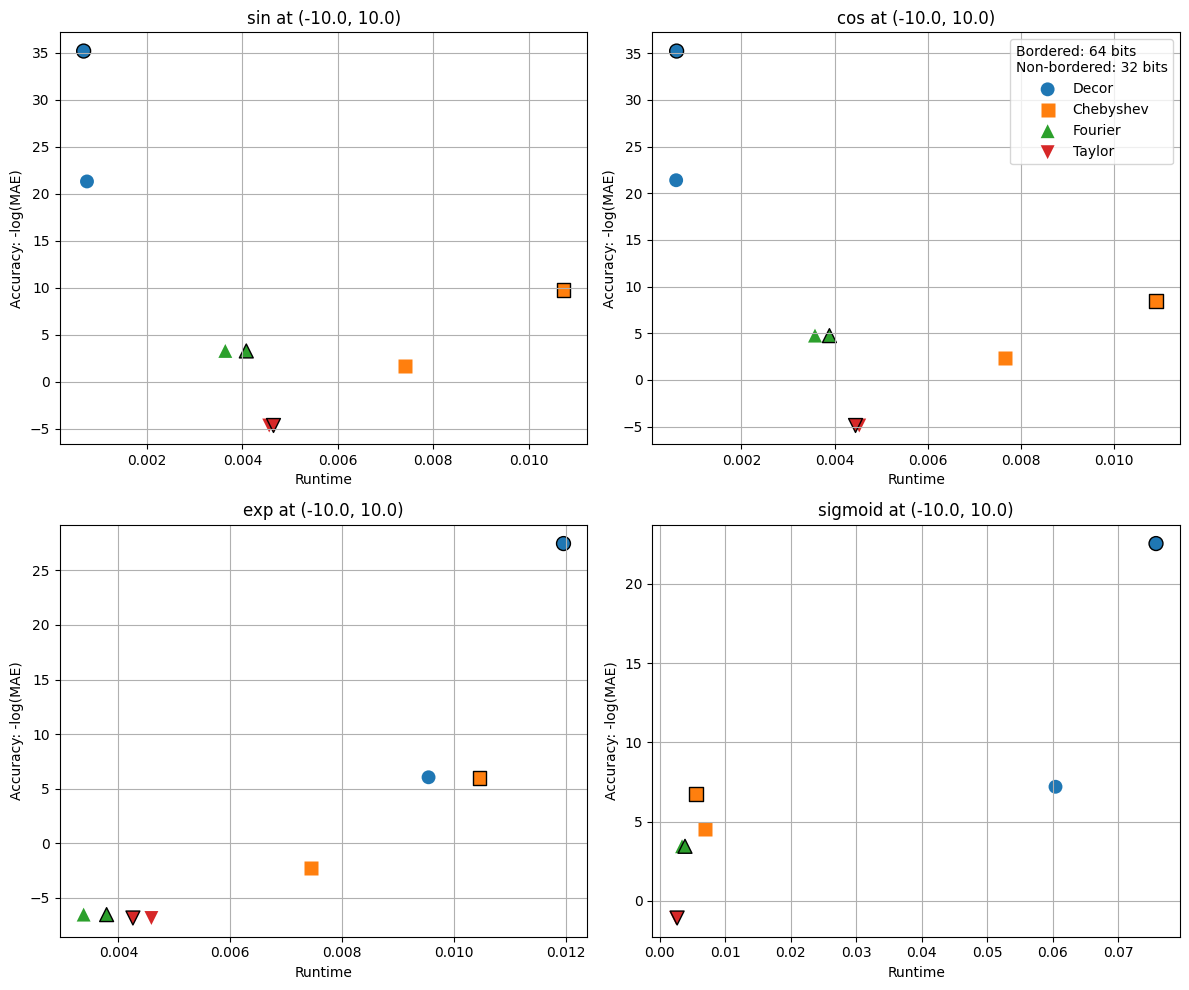

Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)
Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)
Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)
Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)


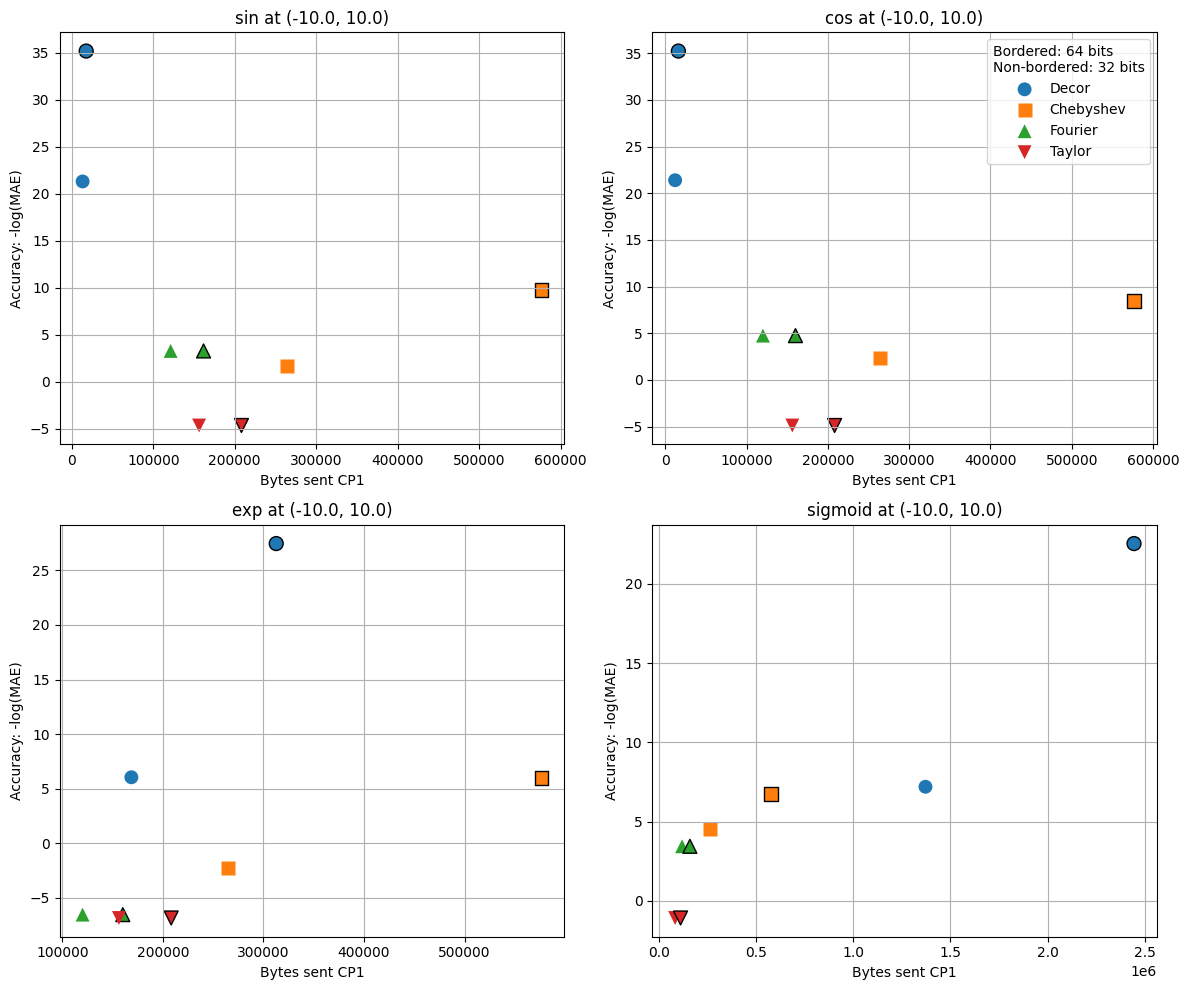

In [64]:
plot_accuracy_vs_perf(df, metric="Runtime")
plot_accuracy_vs_perf(df, metric="Bytes sent CP1")